## Libraries Import

In [25]:
%load_ext autoreload
%autoreload 2
%aimport -pandas
%aimport -pyarrow

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
%pip install pandas pyarrow duckdb matplotlib seaborn torch datasets scikit-learn xgboost lightgbm catboost pypots chronos-forecasting 

Note: you may need to restart the kernel to use updated packages.


In [10]:
import numpy as np
import pandas as pd
# import pandas.core.arrays.arrow.extension_types
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tqdm import tqdm
import warnings
import os
import logging
import duckdb
import gc
import pyarrow as pa
import pyarrow.parquet as pq
import yaml
import pickle
import pandas as pd
import numpy as np
from abc import ABC, abstractmethod
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from pypots.imputation import SAITS, DLinear, TimesNet
from pypots.optim import Adam
import time
from pyexpat import features
from chronos import Chronos2Pipeline

## Dataset builder

In [2]:
class ForecastingDataBuilder:
    def __init__(self, hf_dataset_path="Dingdong-Inc/FreshRetailNet-50K", split="train"):
        self.hf_dataset_path = hf_dataset_path
        self.split = split
        self.raw_data = None
        self.processed_data = None

    def extract_data(self):
        print(f"Downloading {self.hf_dataset_path} ({self.split} split)...")
        dataset = load_dataset(self.hf_dataset_path, split=self.split)
        self.raw_data = dataset.to_pandas()
        return self

    def transform_schema(self):
        """Highly optimized schema mapping to prevent MemoryError."""
        df = self.raw_data.copy()
        
        cols_to_drop = ['sale_amount', 'stock_hour6_22_cnt', 'management_group_id', 'third_category_id']
        df = df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

        # Downcast
        for col in df.columns:
            if df[col].dtype == 'float64':
                df[col] = df[col].astype('float32')
            elif df[col].dtype == 'int64':
                df[col] = df[col].astype('int32')

        weather_cols = ['precpt', 'avg_temperature', 'avg_humidity', 'avg_wind_level']
        if all(col in df.columns for col in weather_cols):
            # Create a simplified string representation to save memory over dictionaries
            df['weather_condition'] = (
                "precpt:" + df['precpt'].astype(str) + 
                "|temp:" + df['avg_temperature'].astype(str)
            )
            df = df.drop(columns=weather_cols)

        print("Exploding 24-hour arrays...")
        df['hour'] = [list(range(24))] * len(df)
        df = df.explode(['hours_sale', 'hours_stock_status', 'hour'])

        df['hours_sale'] = pd.to_numeric(df['hours_sale'], errors='coerce').fillna(0).astype('float32')
        df['hours_stock_status'] = pd.to_numeric(df['hours_stock_status'], errors='coerce').fillna(0).astype('int8')
        df['hour'] = df['hour'].astype('int8')
        
        column_mapping = {
            'hours_sale': 'units_ordered',
            'hours_stock_status': 'stockout_flag',
            'first_category_id': 'product_category',
            'second_category_id': 'product_subcategory',
            'activity_flag': 'is_promotion',
            'city_id': 'location',
            'holiday_flag': 'holiday'
        }
        df = df.rename(columns={k: v for k, v in column_mapping.items() if k in df.columns})
        
        df['date'] = pd.to_datetime(df['dt']) + pd.to_timedelta(df['hour'], unit='h')
        df['day_of_week'] = df['date'].dt.dayofweek.astype('int8')
        df['week_of_year'] = df['date'].dt.isocalendar().week.astype('int8')
        df['month'] = df['date'].dt.month.astype('int8')
        df['year'] = df['date'].dt.year.astype('int16')
        
        missing_required_fields = [
            'stock_on_hand', 'selling_price', 'product_price', 
            'promotion_type', 'is_bulk_order'
        ]
        for field in missing_required_fields:
            if field not in df.columns:
                df[field] = None
                
        if 'dt' in df.columns:
            df = df.drop(columns=['dt'])

        self.processed_data = df
        return self

    def load_data(self, output_format="parquet", filename="ForecastingData"):
        if self.processed_data is None:
            raise ValueError("Call transform_schema() before exporting.")
            
        df = self.processed_data
        
        if output_format == "parquet":
            df.to_parquet(f"{filename}.parquet", index=False, engine="pyarrow")
            print(f"Saved to {filename}.parquet")
            
        elif output_format == "csv":
            df.to_csv(f"{filename}.csv", index=False)
            print(f"Saved to {filename}.csv")
            
        elif output_format == "duckdb":
            # Creates a local relational database file
            conn = duckdb.connect(f"{filename}.duckdb")
            conn.execute("CREATE TABLE forecasting_data AS SELECT * FROM df")
            conn.close()
            print(f"Saved to {filename}.duckdb")

In [ ]:
eval_builder = ForecastingDataBuilder(split="eval")
eval_builder.extract_data().transform_schema().load_data(
    output_format="parquet", 
    filename="ForecastingData_Eval"
)
gc.collect()
train_builder = ForecastingDataBuilder(split="train")
train_builder.extract_data().transform_schema().load_data(
    output_format="parquet", 
    filename="ForecastingData_Train"
)
gc.collect()

5915

## ML Models (Can be expanded)

In [6]:
class BaseForecastingModel(ABC):
    """Abstract base class ensuring all models share the same interface."""
    def __init__(self, params):
        self.params = params
        self.model = None

    @abstractmethod
    def build_model(self):
        pass

    def train(self, X_train, y_train):
        print(f"Training {self.__class__.__name__}...")
        self.model.fit(X_train, y_train)
        return self

    def predict(self, X_test):
        return self.model.predict(X_test)

class XGBoostForecaster(BaseForecastingModel):
    def build_model(self):
        self.model = XGBRegressor(
            objective='count:poisson',
            eval_metric='poisson-nloglik',
            learning_rate=0.05,
            max_delta_step=1,
            n_estimators=500,
            max_depth=6,
            random_state=42
        )
        return self

class RandomForestForecaster(BaseForecastingModel):
    def build_model(self):
        if 'objective' not in self.params:
            self.params['objective'] = 'tweedie'
        self.model = RandomForestRegressor(**self.params)
        return self
class LightGBMForecaster(BaseForecastingModel):
    def build_model(self):
        self.model = LGBMRegressor(**self.params)
        return self

class CatBoostForecaster(BaseForecastingModel):
    def build_model(self):
        self.params['silent'] = True 
        self.params['loss_function'] = 'Tweedie:variance_power=1.5'
        self.model = CatBoostRegressor(**self.params)
        return self

class RidgeForecaster(BaseForecastingModel):
    def build_model(self):
        self.model = Ridge(**self.params)
        return self

class LassoForecaster(BaseForecastingModel):
    def build_model(self):
        self.model = Lasso(**self.params)
        return self

class kNNForecaster(BaseForecastingModel):
    def build_model(self):
        self.model = KNeighborsRegressor(**self.params)
        return self

## Data Preparation

In [7]:
def load_and_downcast(path, sample_size=200000):
    print(f"Using DuckDB to pull {sample_size} rows from {path} out-of-core...")
    
    query = f"SELECT * FROM read_parquet('{path}') LIMIT {sample_size}"
    df = duckdb.query(query).to_df()
    
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
        elif df[col].dtype == 'int64':
            df[col] = df[col].astype('int32')
            
    return df

In [9]:
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    print("Running on Apple Silicon (MPS)")
else:
    print("Running on CPU")

Running on Apple Silicon (MPS)


In [11]:
def recover_latent_demand(df, sequence_length=168, is_train=True, scaler=None,
                        trained_model=None, train_chunk_size=20_000,
                        impute_chunk_size=2_000, model_name="DLINEAR"):

    mode_str = "TRAINING" if is_train else "EVALUATION"
    print(f"Preparing data for Latent Demand Recovery ({mode_str} Mode)...")

    df['true_demand'] = df['units_ordered'].astype(float)
    df.loc[df['stockout_flag'] == 1, 'true_demand'] = np.nan

    features_to_use = ['true_demand', 'selling_price', 'discount', 'hour', 'day_of_week']
    for col in features_to_use:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('float32')

    grouped = df.groupby(['store_id', 'product_id'])
    n_features = len(features_to_use)

    total_windows = sum((len(g) - sequence_length) // sequence_length + 1 
                        for _, g in grouped if len(g) >= sequence_length)

    print(f"  Total windows to build: {total_windows:,}  "
        f"(≈ {total_windows * sequence_length * n_features * 4 / 1e9:.2f} GB float32)")

    X_3d = np.empty((total_windows, sequence_length, n_features), dtype=np.float32)
    indices_map = np.empty(total_windows * sequence_length, dtype=np.int64)

    win_idx, flat_idx = 0, 0
    for _, group in grouped:
        group = group.sort_values('date')
        if len(group) < sequence_length:
            continue
        vals = group[features_to_use].values.astype(np.float32)
        idx  = group.index.values
        
        for i in range(0, len(vals) - sequence_length + 1, sequence_length):
            X_3d[win_idx] = vals[i : i + sequence_length]
            n = sequence_length
            indices_map[flat_idx : flat_idx + n] = idx[i : i + sequence_length]
            win_idx  += 1
            flat_idx += n

    X_3d = X_3d[:win_idx]
    indices_map = indices_map[:flat_idx]
    print(f"  Built tensor: {X_3d.shape}")

    # 2. Standardize
    X_2d_view = X_3d.reshape(-1, n_features)
    if is_train:
        scaler = StandardScaler()
        X_2d_view[:, 1:] = scaler.fit_transform(X_2d_view[:, 1:])
    else:
        if scaler is None:
            raise ValueError("You must provide a fitted scaler when is_train=False")
        X_2d_view[:, 1:] = scaler.transform(X_2d_view[:, 1:])

    # 3. Model Initialization (Lazy Load to save RAM)
    if torch.cuda.is_available():
        compute_device = "cuda"
    elif torch.backends.mps.is_available():
        compute_device = "mps"
    else:
        compute_device = "cpu"

    model_name = model_name.upper()
    if is_train:
        # Lower epochs per chunk since it will see multiple chunks
        base_params = {
            "n_steps": sequence_length,
            "n_features": n_features,
            "epochs": 10, 
            "batch_size": 256,
            "optimizer": Adam(lr=0.001),
            "device": compute_device
        }
        
        if model_name == "SAITS":
            model = SAITS(
                n_steps=sequence_length,
                n_features=n_features,
                n_layers=2,
                d_model=64,
                d_ffn=128,
                n_heads=4,
                d_k=16,
                d_v=16,
                dropout=0.1,
                epochs=25,
                patience=10,
                batch_size=256,
                optimizer=Adam(lr=0.001),
                device=compute_device,
                saving_path="saits_checkpoint.pt"
            )
        elif model_name == "DLINEAR":
            model = DLinear(
                n_steps=sequence_length,
                n_features=n_features,
                moving_avg_window_size=25, 
                epochs=25,
                patience=10,
                batch_size=256,
                optimizer=Adam(lr=0.001),
                device=compute_device,
                saving_path="dlinear_checkpoint.pt"
            )
        elif model_name == "TIMESNET":
            model = TimesNet(
                n_steps=sequence_length,
                n_features=n_features,
                n_layers=2,
                top_k=5,          
                d_model=64,
                d_ffn=128,
                n_kernels=6,      
                dropout=0.1,
                epochs=25,
                patience=10,
                batch_size=256,
                optimizer=Adam(lr=0.001),
                device=compute_device,
                saving_path="timesnet_checkpoint.pt"
            )
        else:
            raise ValueError(f"Model '{model_name}' not recognized.")
    else:
        if trained_model is None:
            raise ValueError("You must provide a trained_model when is_train=False")
        model = trained_model

    # 4. Accumulate Training
    if is_train:
        print(f"  Accumulating training across {win_idx:,} windows...")
        for start in range(0, win_idx, train_chunk_size):
            end = min(start + train_chunk_size, win_idx)
            print(f"    -> Training on chunk {start:,}–{end:,}...")
            
            chunk_data = {"X": X_3d[start:end]}
            model.fit(chunk_data)
            
            del chunk_data; gc.collect()
    else:
        print(f"  Skipping training. Using pre-trained {model_name} for evaluation...")

    # 5. Imputation
    print(f"  Imputing {win_idx:,} windows in chunks of {impute_chunk_size:,}...")
    imputed_3d = np.empty_like(X_3d)

    for start in range(0, win_idx, impute_chunk_size):
        end = min(start + impute_chunk_size, win_idx)
        chunk = {"X": X_3d[start:end]}
        imputed_3d[start:end] = model.impute(chunk)
        if (start // impute_chunk_size) % 5 == 0:
            print(f"    chunk {start:,}–{end:,} done")

    del X_3d; gc.collect()

    # 6. Save Arrays
    suffix = "train" if is_train else "eval"
    print(f"  Saving imputed 3D array with shape: {imputed_3d.shape}...")
    np.save(f'{model_name.lower()}_imputed_output_{suffix}.npy', imputed_3d)
    df.to_parquet(f'{model_name.lower()}_aligned_dataframe_{suffix}.parquet', index=False)

    # 7. Map recovered demand back
    imputed_flat = imputed_3d.reshape(-1, n_features)
    recovered_demand = imputed_flat[:, 0]
    del imputed_3d, imputed_flat; gc.collect()

    df.loc[indices_map, 'true_demand'] = recovered_demand
    df['true_demand'] = df['true_demand'].clip(lower=0)

    print(f" Successfully recovered demand for {(df['stockout_flag'] == 1).sum():,} stockout hours.")

    if is_train:
        return df, scaler, model
    return df

In [12]:
def add_context_features(df):
    """
    Engineers cross-sectional and momentum features to provide the model 
    with broader store and category context, strictly avoiding data leakage.
    """ 

    df = df.sort_values(by=['date']).reset_index(drop=True)
    
    # FEATURE 1: store_traffic_lag_1h
    hourly_store_sales = df.groupby(['store_id', 'date'])['units_ordered'].sum().reset_index()
    hourly_store_sales.rename(columns={'units_ordered': 'store_total_current'}, inplace=True)
    
    hourly_store_sales['store_traffic_lag_1h'] = (
        hourly_store_sales.groupby('store_id')['store_total_current'].shift(1)
    )
    
    hourly_store_sales.drop(columns=['store_total_current'], inplace=True)
    df = df.merge(hourly_store_sales, on=['store_id', 'date'], how='left')


    # FEATURE 2: category_momentum (24-Hour Rolling)
    hourly_cat_sales = df.groupby(['product_category', 'date'])['units_ordered'].sum().reset_index()
    hourly_cat_sales.rename(columns={'units_ordered': 'cat_total_current'}, inplace=True)
    
    def rolling_24h_momentum(group):
        return group['cat_total_current'].shift(1).rolling(window=24, min_periods=1).sum()
        
    hourly_cat_sales['category_momentum'] = (
        hourly_cat_sales.groupby('product_category', group_keys=False).apply(rolling_24h_momentum)
    )
    
    hourly_cat_sales.drop(columns=['cat_total_current'], inplace=True)
    df = df.merge(hourly_cat_sales, on=['product_category', 'date'], how='left')

    df['store_traffic_lag_1h'] = df['store_traffic_lag_1h'].fillna(0)
    df['category_momentum'] = df['category_momentum'].fillna(0)

    return df

In [13]:
def add_days_since_last_sale(df, date_col='date', group_cols=['store_id', 'product_id'], sales_col='units_ordered'):
    """
    Calculates the number of days since the last sale for each (store, product) pair at every hour.
    """
    if not pd.api.types.is_datetime64_any_dtype(df[date_col]):
        df[date_col] = pd.to_datetime(df[date_col])
        
    df = df.sort_values(group_cols + [date_col])
    
    # Create a temporary column to store the date of the last sale for each (store, product) pair
    sale_mask = df[sales_col] > 0
    df.loc[sale_mask, 'last_sale_date'] = df.loc[sale_mask, date_col]
    
    # Forward fill (fill with the last known value) the last sale date for each group
    df['last_sale_date'] = df.groupby(group_cols)['last_sale_date'].ffill()
    
    # Calculate the number of days since the last sale (using dt.total_seconds() divided by 86400 to get days)
    df['days_since_last_sale'] = (df[date_col] - df['last_sale_date']).dt.total_seconds() / (24 * 3600)
    
    # Handle NaN values (e.g., time periods before the first sale of an item)
    # Fill with a default value of -1 so the model understands this as "never sold"
    df['days_since_last_sale'] = df['days_since_last_sale'].fillna(-1)

    # Drop the temporary column
    df = df.drop(columns=['last_sale_date'])
    
    return df

In [14]:
def prepare_data_in_chunks(config, chunk_size_stores=50, model="SAITS"):
    target = config['data']['target_col']
    use_latent = config['training'].get('use_latent_demand', False)
    dl_mode = "latent" if use_latent else "raw"
    
    fitted_scaler = None
    fitted_model = None
    
    for phase, path in [("train", config['data']['train_path']), ("eval", config['data']['eval_path'])]:
        dl_path = f"DL_ready_{phase}_{dl_mode}.parquet"
        
        if os.path.exists(dl_path):
            os.remove(dl_path)
            
        print(f"\nProcessing {phase.upper()} data in chunks...")
        
        all_stores = pd.read_parquet(path, columns=['store_id'])['store_id'].unique()
        store_chunks = [all_stores[i:i + chunk_size_stores] for i in range(0, len(all_stores), chunk_size_stores)]
        
        writer = None
        
        for chunk_idx, stores in enumerate(store_chunks):
            print(f"   -> Processing Chunk {chunk_idx+1}/{len(store_chunks)} ({len(stores)} stores)...")
            
            df_chunk = pd.read_parquet(path, filters=[('store_id', 'in', stores)])
        
            df_chunk = add_days_since_last_sale(df_chunk, date_col='date', sales_col='units_ordered')
            df_chunk = add_context_features(df_chunk)
            
            if use_latent:
                if phase == "train":
                    print(f"Training Recovery Model on TRAIN Chunk {chunk_idx+1}...")
                    df_chunk, fitted_scaler, fitted_model = recover_latent_demand(df_chunk, is_train=True, model_name=model)
                else:
                    print(f"Applying pre-trained {model} to EVAL Chunk {chunk_idx+1}...")
                    df_chunk = recover_latent_demand(
                        df_chunk, is_train=False, scaler=fitted_scaler, trained_model=fitted_model, model_name=model
                    )
                
                target = 'true_demand'

            df_chunk = df_chunk.dropna(subset=[target])
            
            table = pa.Table.from_pandas(df_chunk)
            if chunk_idx == 0:
                writer = pq.ParquetWriter(dl_path, table.schema)
            writer.write_table(table)
            
            del df_chunk, table
            gc.collect()
            
        if writer:
            writer.close()
            
    print(f"\nFinished processing! Data saved to {dl_path}")
    return dl_mode, target

## Model Evaluation

In [15]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    """
    A robust evaluation suite for retail demand forecasting.
    """
    # 1. Standard Metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # 2. WMAPE (Weighted Mean Absolute Percentage Error)
    epsilon = 1e-10
    wmape = np.sum(np.abs(y_true - y_pred)) / (np.sum(y_true) + epsilon)
    
    # 3. Forecast Bias
    total_actual = np.sum(y_true)
    total_predicted = np.sum(y_pred)
    bias_percentage = ((total_predicted - total_actual) / (total_actual + epsilon)) * 100
    
    # 4. Baseline Comparison (Predicting the mean of the evaluation set)
    mean_value = np.mean(y_true)
    baseline_preds = np.full_like(y_true, fill_value=mean_value)
    baseline_mae = mean_absolute_error(y_true, baseline_preds)
    
    print(f"\n" + "="*40)
    print(f" {model_name.upper()} COMPREHENSIVE EVALUATION")
    print(f"="*40)
    print(f"Standard Metrics:")
    print(f"  • MAE:   {mae:.4f}")
    print(f"  • RMSE:  {rmse:.4f}")
    print(f"\nRetail Metrics:")
    print(f"  • WMAPE: {wmape:.2%}")
    print(f"  • Bias:  {bias_percentage:+.2f}% (Overall volume difference)")
    print(f"\nBaseline Comparison:")
    print(f"  • Baseline (Mean) MAE: {baseline_mae:.4f}")

    improvement = ((baseline_mae - mae) / baseline_mae) * 100
    print(f"  • Model beats baseline by: {improvement:.2f}%")
    print(f"="*40 + "\n")
    
    return {"MAE": mae, "RMSE": rmse, "WMAPE": wmape, "Bias": bias_percentage}

In [16]:
def plot_visual_evaluation(y_true, y_pred, model_pipeline, feature_names, num_hours=168):
    """
    Generates a 3-part visual diagnostic dashboard for the forecasting model.
    num_hours=168 defaults to plotting exactly 1 week of hourly data (24 * 7).
    """

    y_true = np.array(y_true)
    print(len(y_true))
    y_pred = np.array(y_pred)
    print(len(y_pred))
    

    sns.set_theme(style="whitegrid")
    fig = plt.figure(figsize=(16, 12))
    

    for i in range(1, 2):
        plt.figure(figsize=(14, 4))
        ax1 = plt.gca()
        ax1.plot(y_true[(i-1)*num_hours:(i)*num_hours], label='Actual Sales (Normalized)', marker='.', color='#1f77b4', linewidth=1.5)
        ax1.plot(y_pred[(i-1)*num_hours:(i)*num_hours], label='Predicted Sales', marker='.', color='#ff7f0e', linewidth=1.5, alpha=0.8)

        ax1.set_title(f'Demand Forecast vs. Reality (From { (i-1)*num_hours } to { i*num_hours })', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Units Ordered')
        ax1.set_xlabel('Time (Hours sequentially)')
        ax1.legend(loc='upper right')
        plt.tight_layout()
        plt.show()
    
    ax2 = plt.figure(figsize=(8, 8)).gca()
    ax2.scatter(y_true, y_pred, alpha=0.3, color='purple', edgecolor='none')
    
    max_val = max(np.max(y_true), np.max(y_pred))
    ax2.plot([0, max_val], [0, max_val], color='black', linestyle='--', label='Perfect Prediction (1:1)')
    
    ax2.set_title('Prediction Accuracy & Bias', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Actual Units Ordered')
    ax2.set_ylabel('Predicted Units Ordered')
    ax2.legend()
    
    # ax3 = plt.figure(figsize=(8, 8)).gca()
    
    # if model_pipeline is not None and hasattr(model_pipeline, 'named_steps'):
    #     trained_model = model_pipeline.named_steps.get('model')
    #     if trained_model is not None and hasattr(trained_model, 'feature_importances_'):
    #         importances = trained_model.feature_importances_
    #         fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    #         fi_df = fi_df.sort_values(by='Importance', ascending=True).tail(10)
    #         ax3.barh(fi_df['Feature'], fi_df['Importance'], color='teal')
    #         ax3.set_title('Top 10 Drivers of Demand (Feature Importance)', fontsize=12, fontweight='bold')
    #         ax3.set_xlabel('Relative Importance Score')
    #     else:
    #         ax3.text(0.5, 0.5, "Feature Importance not available for this model type.", 
    #                  ha='center', va='center', fontsize=12)
    # else:
    #     ax3.text(0.5, 0.5, "Feature Importance not available (no pipeline provided).", 
    #              ha='center', va='center', fontsize=12)

    plt.tight_layout()
    plt.show()

## Training Pipeline

In [17]:
def get_or_prepare_data(config, force_reprep=False, model="SAITS"):
    """
    Checks for DL-ready Parquet files. If missing, runs the chunked preparation pipeline safely.
    RETURNS: The file paths to the Parquet cache, NOT the DataFrames.
    """
    mode = "latent" if config['training'].get('use_latent_demand', False) else "raw"
    dl_train_path = f"DL_ready_train_{mode}_{model}.parquet"
    dl_eval_path  = f"DL_ready_eval_{mode}_{model}.parquet"

    if not os.path.exists(dl_train_path) or not os.path.exists(dl_eval_path) or force_reprep:
        print(f"[CACHE MISS] Running out-of-core Data Preparation (SAITS & Features)...")
        prepare_data_in_chunks(config, chunk_size_stores=50, model=model)
    else:
        print(f"[CACHE HIT] Found existing DL-ready Parquet files. Skipping chunked prep.")
    return dl_train_path, dl_eval_path

In [21]:
def run_training_pipeline(model_type=None, model_save_path=None, force_reprep=False, chunk_size_stores=50, recover_model="SAITS"):
    with open("config.yaml", "r") as f:
        config = yaml.safe_load(f)
    model_save_path = f"{model_save_path}_{model_type.lower()}.pkl" if model_save_path else None
    train_path, eval_path = get_or_prepare_data(config, force_reprep, model=recover_model)
    target = 'true_demand' if config['training'].get('use_latent_demand', False) else config['data']['target_col']
    num_cols = config['data']['num_cols'].copy()
    if 'days_since_last_sale' not in num_cols:
        num_cols.append('days_since_last_sale')
    cat_cols = config['data']['cat_cols']

    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value=0)), 
        ('scaler', StandardScaler())
    ])
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value=-1)),
        ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-2))
    ])
    preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])

    if model_type is None:
        model_type = config['training'].get('model_type', 'xgboost')
    model_type = model_type.lower()
    params = config['model_params'].get(model_type, {})
    
    if model_type == "xgboost":
        params['tree_method'] = 'hist'
        params['device'] = 'cuda'

    registry = {
        "xgboost": XGBoostForecaster,
        "random_forest": RandomForestForecaster,
        "lightgbm": LightGBMForecaster,
        "catboost": CatBoostForecaster,
        "ridge": RidgeForecaster,
        "lasso": LassoForecaster,
        "knn": kNNForecaster
    }
    
    if model_type not in registry:
        raise ValueError(f"Model {model_type} not supported.")
        
    forecaster = registry[model_type](params).build_model()

    print(f"\nStarting Out-of-Core Training for {model_type.upper()} on {recover_model.upper()}-Recovered Demand...")
    start_time = time.time()
    
    all_train_stores = pd.read_parquet(train_path, columns=['store_id'])['store_id'].unique()
    store_chunks = [all_train_stores[i:i + chunk_size_stores] for i in range(0, len(all_train_stores), chunk_size_stores)]
    
    is_preprocessor_fitted = False

    for chunk_idx, stores in enumerate(store_chunks):
        print(f"   -> Training on Chunk {chunk_idx+1}/{len(store_chunks)} (Stores: {len(stores)})...")
        
        df_chunk = pd.read_parquet(train_path, filters=[('store_id', 'in', stores)])
        # 1. Drop rows without a target (You can't train without an answer key!)
        df_chunk = df_chunk.dropna(subset=[target])
        
        X_chunk = df_chunk[num_cols + cat_cols].copy()
        y_chunk = df_chunk[target]
        
        # 2. Crush 'inf' values into NaNs
        X_chunk = X_chunk.replace([np.inf, -np.inf], float('nan'))
        
        # 3. Force numeric columns to float64 (Converts invisible pd.NA into np.nan!)
        for col in num_cols:
            X_chunk[col] = X_chunk[col].astype(float)
            
        # 4. Force categoricals to strings (Turns weird nulls into safe text categories)
        for col in cat_cols:
            X_chunk[col] = X_chunk[col].astype(str).replace(['<NA>', 'nan', 'None'], 'missing')
        
        if not is_preprocessor_fitted:
            X_processed = preprocessor.fit_transform(X_chunk)
            is_preprocessor_fitted = True
        else:
            X_processed = preprocessor.transform(X_chunk)
            
        if chunk_idx == 0:
            forecaster.model.fit(X_processed, y_chunk)
            
        else:
            if model_type == "xgboost":
                forecaster.model.fit(X_processed, y_chunk, xgb_model=forecaster.model)
                
            elif model_type == "lightgbm":
                forecaster.model.fit(X_processed, y_chunk, init_model=forecaster.model)
                
            elif model_type == "catboost":
                forecaster.model.fit(X_processed, y_chunk, init_model=forecaster.model)
                
            elif model_type in ["ridge", "lasso"]:
                if hasattr(forecaster.model, 'partial_fit'):
                    forecaster.model.partial_fit(X_processed, y_chunk)

        del df_chunk, X_chunk, X_processed, y_chunk
        gc.collect()

    print(f"Incremental Training completed in {time.time() - start_time:.2f} seconds!")

    print("\nEvaluating Model on Eval Dataset...")
    
    df_eval = pd.read_parquet(eval_path)
    X_eval, y_eval = df_eval[num_cols + cat_cols], df_eval[target]
    
    X_eval_processed = preprocessor.transform(X_eval)
    predictions = forecaster.model.predict(X_eval_processed)
    
    evaluate_model(y_eval, predictions, model_type.upper())
    

    final_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', forecaster.model)
    ])
    plot_visual_evaluation(y_eval, predictions, model_pipeline=final_pipeline, feature_names=num_cols + cat_cols)
    
    save_path = model_save_path if model_save_path else config['training'].get('model_save_path', f"{model_type}_pipeline.pkl")
    with open(save_path, "wb") as f:
        pickle.dump(final_pipeline, f)
        
    print(f"\nSaved full inference pipeline to {save_path}")

## Models

### xgboost

In [22]:
run_training_pipeline(model_type="xgboost", model_save_path="trained_model_xgboost.pkl", recover_model="DLINEAR")
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
elif torch.backends.mps.is_available():
    torch.mps.empty_cache()

FileNotFoundError: [Errno 2] No such file or directory: 'config.yaml'

### Random Forest

[CACHE HIT] Found existing DL-ready Parquet files. Skipping chunked prep.

Starting Out-of-Core Training for RANDOM_FOREST...
   -> Training on Chunk 1/18 (Stores: 50)...


E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['selling_price']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\utils\extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\utils\extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\utils\extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


   -> Training on Chunk 2/18 (Stores: 50)...


E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['selling_price']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


   -> Training on Chunk 3/18 (Stores: 50)...


...

E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['selling_price']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


Incremental Training completed in 2987.81 seconds!

Evaluating Model on Eval Dataset...


E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['selling_price']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(



 RANDOM_FOREST COMPREHENSIVE EVALUATION
Standard Metrics:
  • MAE:   0.0320
  • RMSE:  0.1081

Retail Metrics:
  • WMAPE: 60.48%
  • Bias:  -3.03% (Overall volume difference)

Baseline Comparison:
  • Baseline (Mean) MAE: 0.0739
  • Model beats baseline by: 56.74%

8400000
8400000


<Figure size 1600x1200 with 0 Axes>

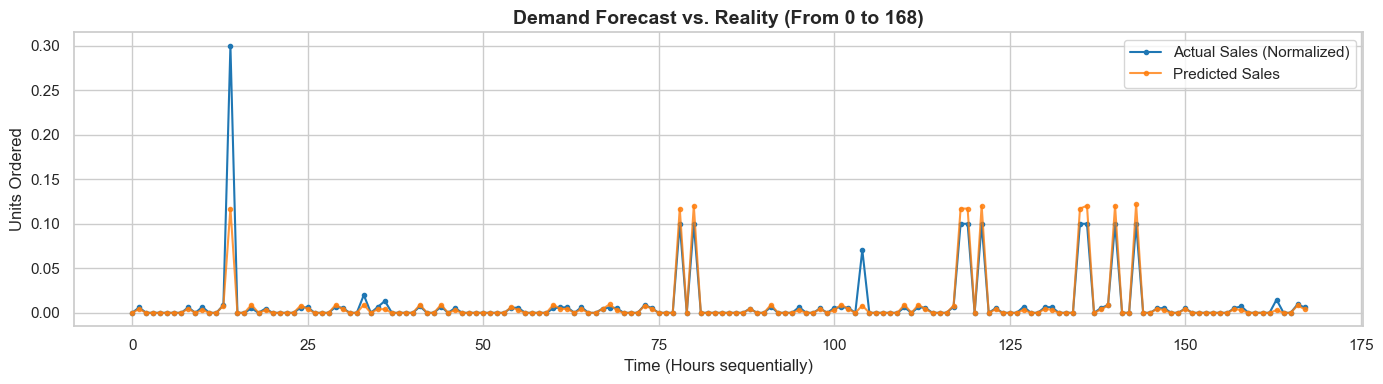

C:\Users\tbplo\AppData\Local\Temp\ipykernel_22820\3534912593.py:59: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
E:\miniconda\envs\retail_ml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


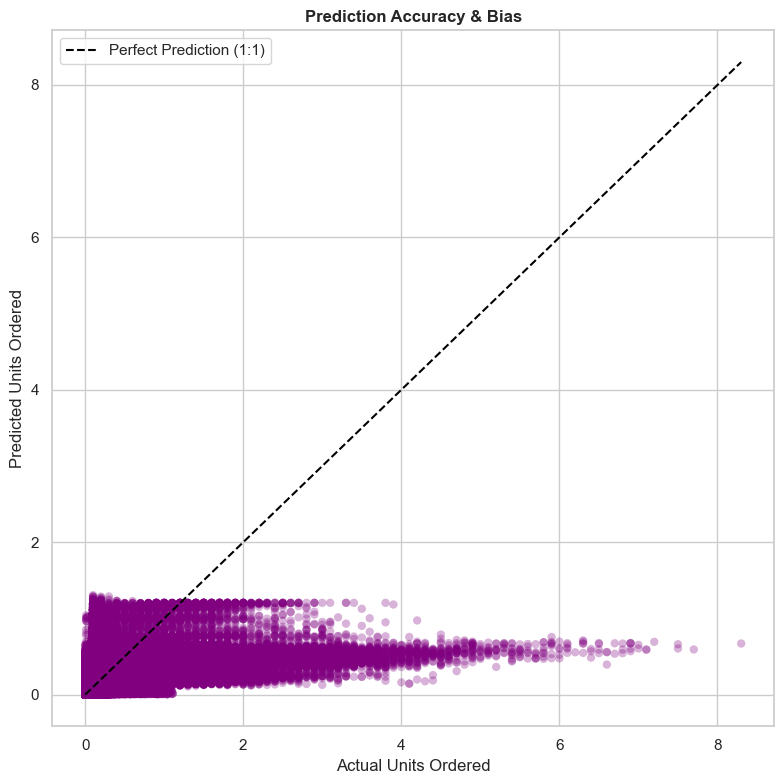


Saved full inference pipeline to trained_model_random_forest.pkl


In [ ]:
run_training_pipeline(model_type="random_forest", model_save_path="trained_model_random_forest.pkl")
gc.collect()
torch.cuda.empty_cache()

### lightgbm

[CACHE HIT] Found existing DL-ready Parquet files. Skipping chunked prep.

Starting Out-of-Core Training for LIGHTGBM...
   -> Training on Chunk 1/18 (Stores: 50)...


E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['selling_price']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\utils\extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\utils\extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\utils\extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.232858 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1316
[LightGBM] [Info] Number of data points in the train set: 9358248, number of used features: 17
[LightGBM] [Info] Start training from score 0.045355
   -> Training on Chunk 2/18 (Stores: 50)...


E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['selling_price']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.228251 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1268
[LightGBM] [Info] Number of data points in the train set: 9444315, number of used features: 17
   -> Training on Chunk 3/18 (Stores: 50)...


...

E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['selling_price']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.175704 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1240
[LightGBM] [Info] Number of data points in the train set: 5247639, number of used features: 18
Incremental Training completed in 1219.46 seconds!

Evaluating Model on Eval Dataset...


E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['selling_price']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



 LIGHTGBM COMPREHENSIVE EVALUATION
Standard Metrics:
  • MAE:   0.0324
  • RMSE:  0.0817

Retail Metrics:
  • WMAPE: 61.33%
  • Bias:  -4.62% (Overall volume difference)

Baseline Comparison:
  • Baseline (Mean) MAE: 0.0739
  • Model beats baseline by: 56.14%

8400000
8400000


<Figure size 1600x1200 with 0 Axes>

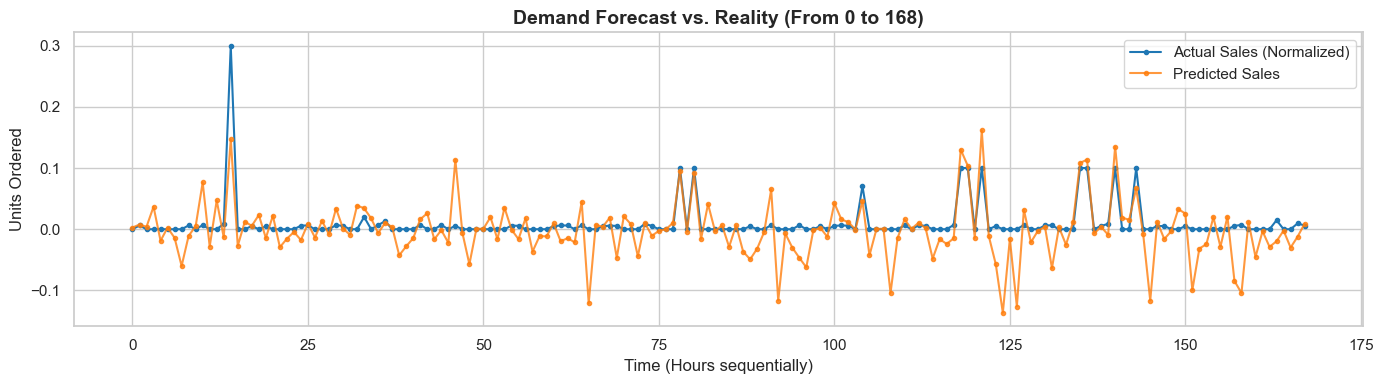

C:\Users\tbplo\AppData\Local\Temp\ipykernel_22820\3534912593.py:59: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
E:\miniconda\envs\retail_ml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


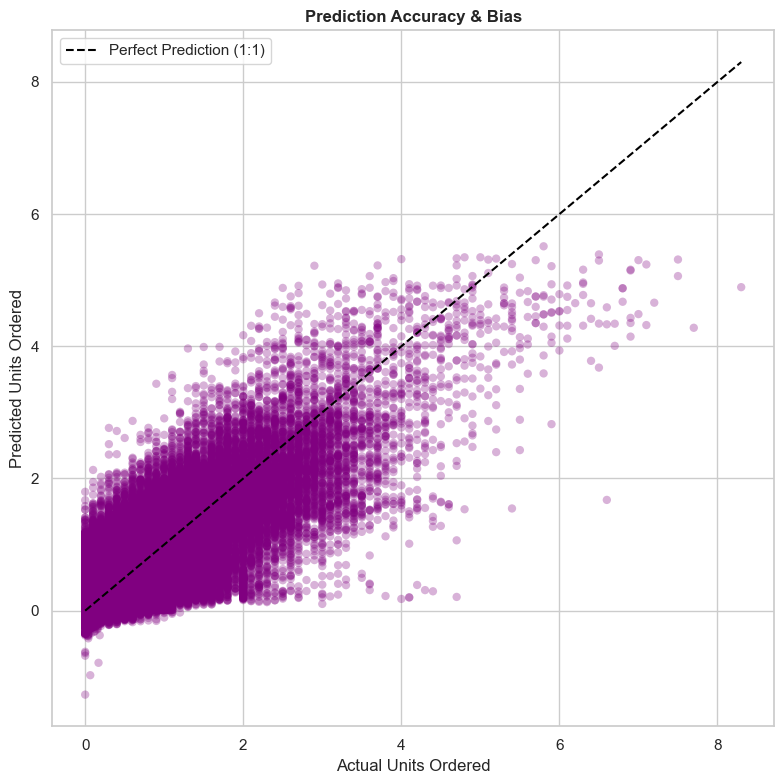


Saved full inference pipeline to trained_model_lightgbm.pkl


: 

In [ ]:
run_training_pipeline(model_type="lightgbm", model_save_path="trained_model_lightgbm.pkl")
gc.collect()
torch.cuda.empty_cache()

### catboost

[CACHE HIT] Found existing DL-ready Parquet files. Skipping chunked prep.

Starting Out-of-Core Training for CATBOOST...
   -> Training on Chunk 1/18 (Stores: 50)...


E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['selling_price']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(
E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\utils\extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\utils\extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\utils\extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


   -> Training on Chunk 2/18 (Stores: 50)...


E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['selling_price']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


   -> Training on Chunk 3/18 (Stores: 50)...


...

E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['selling_price']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


Incremental Training completed in 814.89 seconds!

Evaluating Model on Eval Dataset...


E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['selling_price']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(



 CATBOOST COMPREHENSIVE EVALUATION
Standard Metrics:
  • MAE:   0.0275
  • RMSE:  0.1024

Retail Metrics:
  • WMAPE: 51.99%
  • Bias:  -8.55% (Overall volume difference)

Baseline Comparison:
  • Baseline (Mean) MAE: 0.0739
  • Model beats baseline by: 62.82%

8400000
8400000


<Figure size 1600x1200 with 0 Axes>

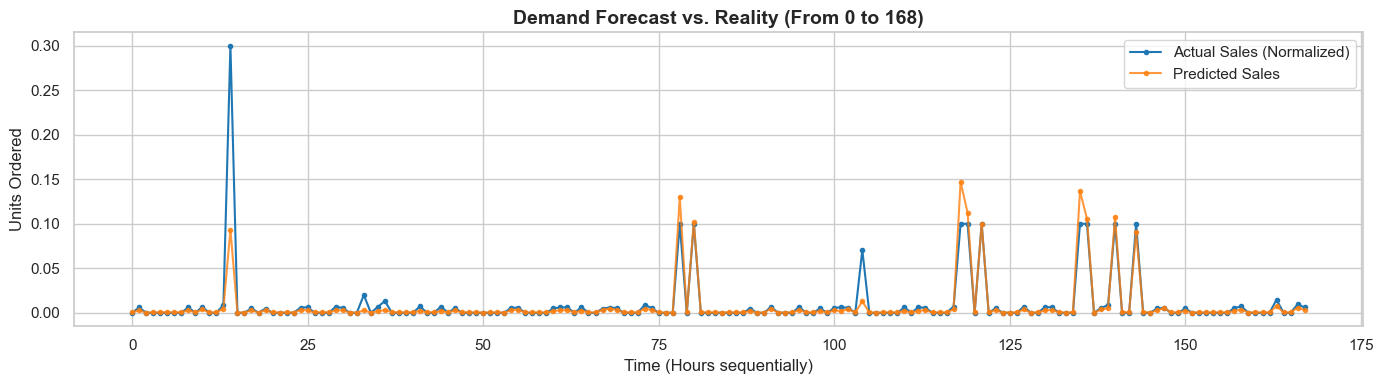

C:\Users\tbplo\AppData\Local\Temp\ipykernel_12656\3534912593.py:59: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
E:\miniconda\envs\retail_ml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


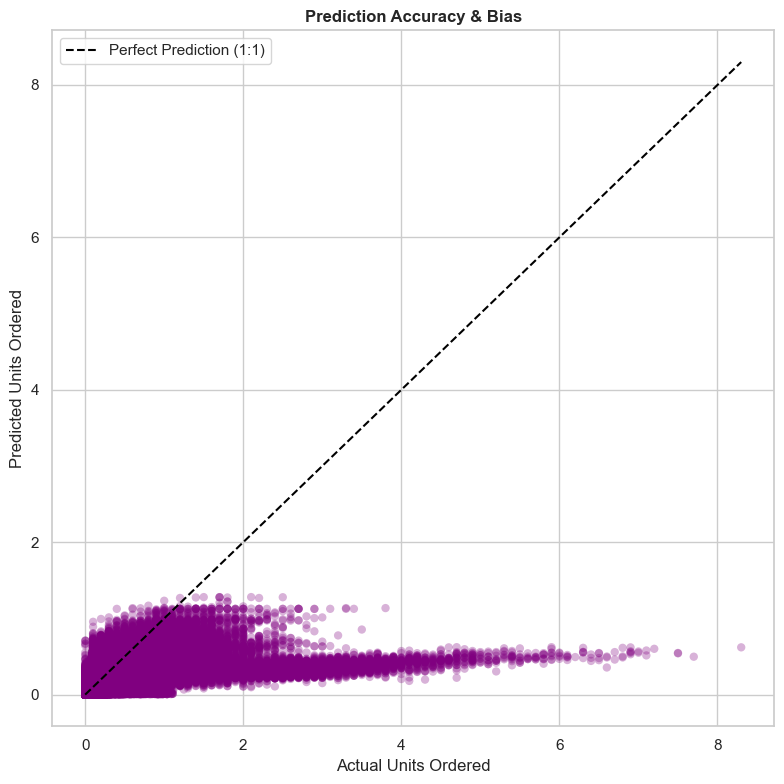


Saved full inference pipeline to trained_model_catboost.pkl


In [16]:
run_training_pipeline(model_type="catboost", model_save_path="trained_model_catboost.pkl")
gc.collect()
torch.cuda.empty_cache()

### lasso

[CACHE HIT] Found existing DL-ready Parquet files. Skipping chunked prep.

Starting Out-of-Core Training for LASSO...
   -> Training on Chunk 1/18 (Stores: 50)...


E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['stock_on_hand' 'selling_price' 'product_price']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


   -> Training on Chunk 2/18 (Stores: 50)...


E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['stock_on_hand' 'selling_price' 'product_price']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


   -> Training on Chunk 3/18 (Stores: 50)...


...

E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['stock_on_hand' 'selling_price' 'product_price']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(


Incremental Training completed in 1161.84 seconds!

Evaluating Model on Eval Dataset...


E:\miniconda\envs\retail_ml\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['stock_on_hand' 'selling_price' 'product_price']. At least one non-missing value is needed for imputation with strategy='constant'.
  warnings.warn(



 LASSO COMPREHENSIVE EVALUATION
Standard Metrics:
  • MAE:   0.0703
  • RMSE:  0.1420

Retail Metrics:
  • WMAPE: 133.00%
  • Bias:  -14.20% (Overall volume difference)

Baseline Comparison:
  • Baseline (Mean) MAE: 0.0739
  • Model beats baseline by: 4.89%

8400000
8400000


<Figure size 1600x1200 with 0 Axes>

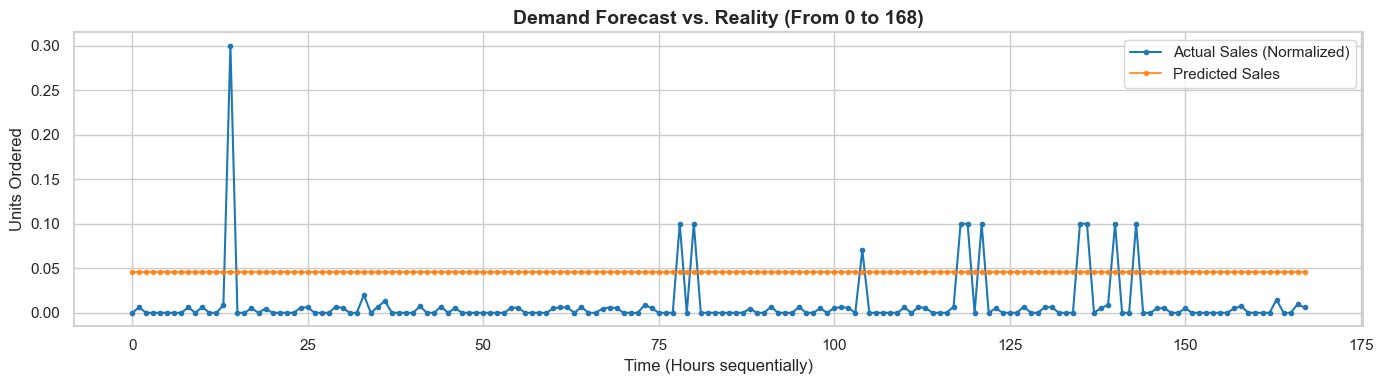

C:\Users\tbplo\AppData\Local\Temp\ipykernel_28392\3534912593.py:59: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
E:\miniconda\envs\retail_ml\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


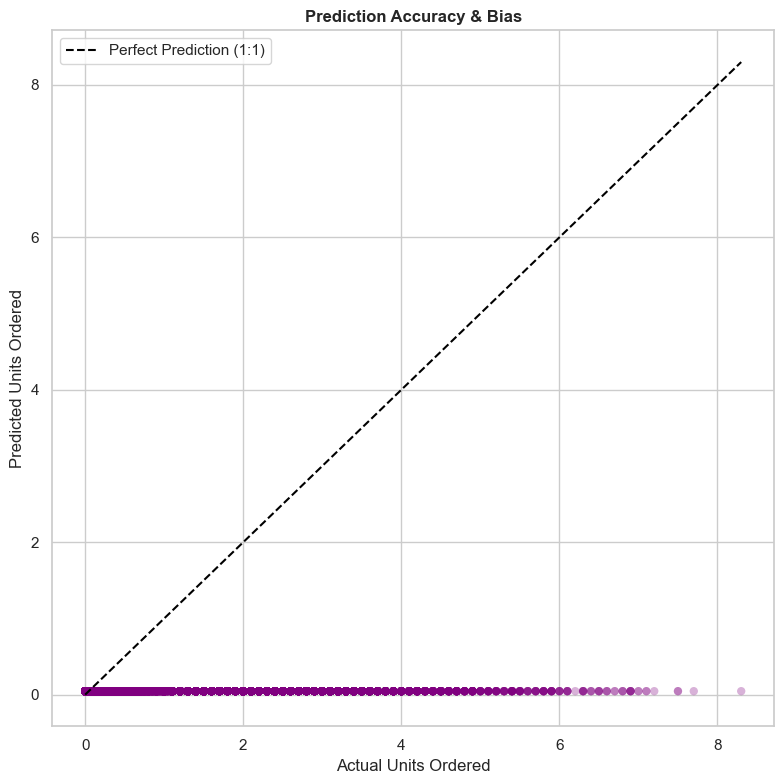


Saved full inference pipeline to trained_model_knn.pkl


7041

In [15]:
run_training_pipeline(model_type="lasso", model_save_path="trained_model_knn.pkl")
gc.collect()

## Deep learning models

In [33]:
class RetailTimeSeriesDataset(Dataset):
    """
    Groups data by store & product, then generates 3D sliding windows.
    Separates continuous features from categorical time features for embeddings.
    Returns: (X_cont, X_hour, X_day), y
    """
    def __init__(self, df, target_col, cont_cols, group_cols, seq_length=168):
        self.seq_length = seq_length
        self.cont_cols = cont_cols
        
        samples_X_cont, samples_X_hour, samples_X_day, samples_y = [], [], [], []
        skipped = 0

        print("  Building 3D Tensors (sliding windows)...")
        for _, group in df.groupby(group_cols):
            group = group.sort_values('date').reset_index(drop=True)

            if len(group) <= seq_length:
                skipped += 1
                continue

            cont_vals = group[cont_cols].values
            hour_vals = group['hour'].values
            day_vals  = group['day_of_week'].values
            targets   = group[target_col].values

            for i in range(len(group) - seq_length):
                samples_X_cont.append(cont_vals[i : i + seq_length])
                samples_X_hour.append(hour_vals[i : i + seq_length])
                samples_X_day.append(day_vals[i : i + seq_length])
                samples_y.append(targets[i + seq_length])

        if skipped:
            print(f"Skipped {skipped} groups shorter than seq_length={seq_length}")

        self.X_cont = torch.tensor(np.array(samples_X_cont), dtype=torch.float32)
        self.X_hour = torch.tensor(np.array(samples_X_hour), dtype=torch.long)
        self.X_day  = torch.tensor(np.array(samples_X_day), dtype=torch.long)
        self.y      = torch.tensor(np.array(samples_y), dtype=torch.float32).unsqueeze(1)
        
        print(f"Tensor shape: X_cont={self.X_cont.shape}, X_hour={self.X_hour.shape}, X_day={self.X_day.shape}, y={self.y.shape}  ({len(self)} samples)")

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (self.X_cont[idx], self.X_hour[idx], self.X_day[idx]), self.y[idx]

In [34]:
class RecurrentForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2, model_type='lstm'):
        super().__init__()
        self.hour_embed = nn.Embedding(num_embeddings=24, embedding_dim=6)
        self.day_embed = nn.Embedding(num_embeddings=7, embedding_dim=3)
        
        total_input_size = input_size + 6 + 3

        rnn_cls = nn.LSTM if model_type.lower() == 'lstm' else nn.GRU
        self.rnn = rnn_cls(
            total_input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, 1)
        )
        self.softplus = nn.Softplus() 

    def forward(self, x_cont, x_hour, x_day): 
        hour_emb = self.hour_embed(x_hour)
        day_emb = self.day_embed(x_day)
        
        x_combined = torch.cat([x_cont, hour_emb, day_emb], dim=2)
        out, _ = self.rnn(x_combined)
        final = self.layer_norm(out[:, -1, :])        
        return self.softplus(self.head(final)) + 1e-6

In [35]:
def train_deep_learning(train_df, val_df, feature_cols, group_cols,
                        target_col='true_demand', model_type='lstm',
                        seq_length=168, hidden_size=128, num_layers=2,
                        batch_size=256, epochs=20, lr=1e-3):
    """
    End-to-end DL training with:
    NaN/NA cleaning + StandardScaler fitted on train, applied to both splits
    Validation loss tracking + ReduceLROnPlateau scheduler
    Gradient clipping and early stopping
    Returns (model, val_dataloader, device) for downstream evaluation
    """
    device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
    print(f"\n{'='*55}")
    print(f"  Training {model_type.upper()} on {device}")
    print(f"{'='*55}")

    train_df = train_df.copy()
    val_df   = val_df.copy()

    for col in feature_cols + [target_col]:
        for df in (train_df, val_df):
            df[col] = pd.to_numeric(df[col], errors='coerce').astype('float32')
            df[col] = df[col].fillna(0.0)

    scaler = StandardScaler()
    train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols].values)
    val_df[feature_cols]   = scaler.transform(val_df[feature_cols].values)

    train_df[target_col] = train_df[target_col].clip(lower=0)
    val_df[target_col]   = val_df[target_col].clip(lower=0)
    
    print(f"  Target raw constraints: min={train_df[target_col].min():.3f}, "
          f"max={train_df[target_col].max():.3f}")

    print("\n[Train Set]")
    train_dataset = RetailTimeSeriesDataset(
        train_df, target_col, feature_cols, group_cols, seq_length)
    print("[Validation Set]")
    val_dataset = RetailTimeSeriesDataset(
        val_df, target_col, feature_cols, group_cols, seq_length)

    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=True, pin_memory=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size,
                              shuffle=False, pin_memory=True)

    model = RecurrentForecaster(
        input_size=len(feature_cols),
        hidden_size=hidden_size,
        num_layers=num_layers,
        model_type=model_type,
    ).to(device) 

    criterion = nn.PoissonNLLLoss(log_input=False, full=False)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=3, factor=0.5)

    best_val_loss = float('inf')
    best_state    = None
    patience_ctr  = 0
    patience_limit = 5

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for (x_cont, x_hour, x_day), by in train_loader:
            x_cont = x_cont.to(device)
            x_hour = x_hour.to(device)
            x_day  = x_day.to(device)
            by     = by.to(device)
            optimizer.zero_grad()
            
            predictions = model(x_cont, x_hour, x_day).squeeze()
            targets = by.squeeze()
            
            loss = criterion(predictions, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for (x_cont, x_hour, x_day), by in val_loader:
                x_cont = x_cont.to(device)
                x_hour = x_hour.to(device)
                x_day  = x_day.to(device)
                by     = by.to(device)
                
                predictions = model(x_cont, x_hour, x_day).squeeze()
                targets = by.squeeze()
                
                val_loss += criterion(predictions, targets).item()

        avg_train = train_loss / len(train_loader)
        avg_val   = val_loss   / len(val_loader)
        scheduler.step(avg_val)
        cur_lr = optimizer.param_groups[0]['lr']

        print(f"  Epoch {epoch:02d}/{epochs} │ Train: {avg_train:.4f} │ "
              f"Val: {avg_val:.4f} │ LR: {cur_lr:.2e}")

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience_limit:
                print(f"Early stopping triggered at epoch {epoch}")
                break

    if best_state is not None:    
        model.load_state_dict(best_state)
    print(f"  Best validation loss: {best_val_loss:.4f}\n")
    return model, val_loader, device

In [36]:
def evaluate_pytorch_model(model, val_dataloader, device, model_name="LSTM"):
    """
    Runs inference on a PyTorch validation DataLoader, computes metrics
    via the shared evaluate_model() function, and draws a self-contained
    2-panel diagnostic plot (time-series overlay + scatter).
    """
    print(f"\n── Running inference: {model_name} ──")
    model.eval()

    all_preds, all_actuals = [], []
    with torch.no_grad():
        for (x_cont, x_hour, x_day), by in val_dataloader:
            x_cont = x_cont.to(device)
            x_hour = x_hour.to(device)
            x_day  = x_day.to(device)
            by     = by.to(device)
            preds = model(x_cont, x_hour, x_day)
            all_preds.extend(preds.cpu().numpy().flatten())
            all_actuals.extend(by.cpu().numpy().flatten())

    y_true = np.array(all_actuals)
    y_pred = np.array(all_preds)

    # ---- Inverse log1p to recover original demand scale ----
    # y_true = np.expm1(y_true_log)
    # y_pred = np.expm1(y_pred_log)
    # y_pred = np.clip(y_pred, 0, None)  # safety: ensure no negative predictions

    # ---- Numeric evaluation (reuses your existing function) ----
    evaluate_model(y_true, y_pred, model_name)

    # ---- Visual evaluation (self-contained, no sklearn pipeline needed) ----
    num_hours = min(168, len(y_true))
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Panel 1 – Time-series overlay
    axes[0].plot(y_true[:num_hours], label='Actual', marker='.', linewidth=1.2)
    axes[0].plot(y_pred[:num_hours], label='Predicted', marker='.', linewidth=1.2, alpha=0.8)
    axes[0].set_title(f'{model_name}: Forecast vs Reality (first {num_hours}h)')
    axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Demand')
    axes[0].legend()

    # Panel 2 – Scatter (actual vs predicted)
    axes[1].scatter(y_true, y_pred, alpha=0.25, s=8, color='purple')
    mx = max(y_true.max(), y_pred.max())
    axes[1].plot([0, mx], [0, mx], 'k--', label='Perfect 1:1')
    axes[1].set_title(f'{model_name}: Prediction Scatter')

    axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')    
    
    axes[1].legend();    plt.tight_layout(); plt.show()
    return y_true, y_pred

⚡ Loading DL-ready DataFrames from DL_ready_train_latent.parquet / DL_ready_eval_latent.parquet...
Using DuckDB to pull 500000 rows from DL_ready_train_latent.parquet out-of-core...
Using DuckDB to pull 200000 rows from DL_ready_eval_latent.parquet out-of-core...
  Train: 500,000 | Val: 200,000 | Target: true_demand

  Training LSTM on cuda
  Target raw constraints: min=0.000, max=3.400

[Train Set]
  Building 3D Tensors (sliding windows)...
  ✓ Tensor shape: X_cont=torch.Size([488888, 24, 7]), X_hour=torch.Size([488888, 24]), X_day=torch.Size([488888, 24]), y=torch.Size([488888, 1])  (488888 samples)
[Validation Set]
  Building 3D Tensors (sliding windows)...
  ✓ Tensor shape: X_cont=torch.Size([171416, 24, 7]), X_hour=torch.Size([171416, 24]), X_day=torch.Size([171416, 24]), y=torch.Size([171416, 1])  (171416 samples)
  Epoch 01/20 │ Train: 0.1483 │ Val: 0.1780 │ LR: 1.00e-03
  Epoch 02/20 │ Train: 0.1445 │ Val: 0.1756 │ LR: 1.00e-03
  Epoch 03/20 │ Train: 0.1435 │ Val: 0.1762 │ LR: 

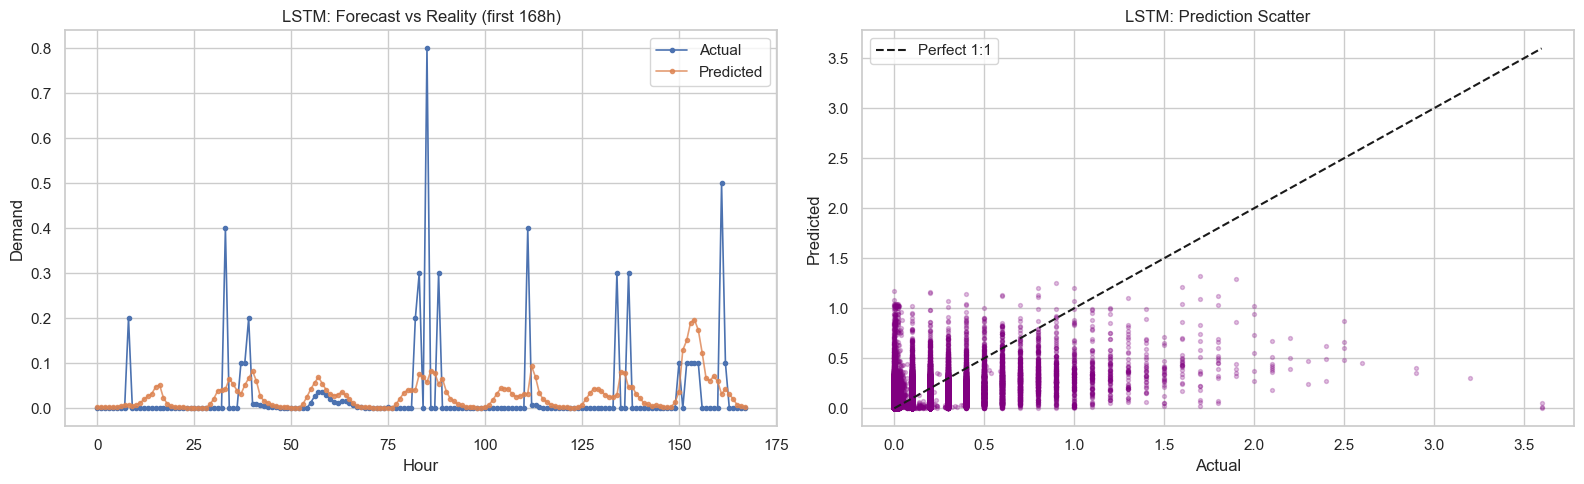


  Training GRU on cuda
  Target raw constraints: min=0.000, max=3.400

[Train Set]
  Building 3D Tensors (sliding windows)...
  ✓ Tensor shape: X_cont=torch.Size([488888, 24, 7]), X_hour=torch.Size([488888, 24]), X_day=torch.Size([488888, 24]), y=torch.Size([488888, 1])  (488888 samples)
[Validation Set]
  Building 3D Tensors (sliding windows)...
  ✓ Tensor shape: X_cont=torch.Size([171416, 24, 7]), X_hour=torch.Size([171416, 24]), X_day=torch.Size([171416, 24]), y=torch.Size([171416, 1])  (171416 samples)
  Epoch 01/20 │ Train: 0.1480 │ Val: 0.1807 │ LR: 1.00e-03
  Epoch 02/20 │ Train: 0.1442 │ Val: 0.1728 │ LR: 1.00e-03
  Epoch 03/20 │ Train: 0.1434 │ Val: 0.1751 │ LR: 1.00e-03
  Epoch 04/20 │ Train: 0.1429 │ Val: 0.1735 │ LR: 1.00e-03
  Epoch 05/20 │ Train: 0.1425 │ Val: 0.1746 │ LR: 1.00e-03
  Epoch 06/20 │ Train: 0.1421 │ Val: 0.1733 │ LR: 5.00e-04
  Epoch 07/20 │ Train: 0.1413 │ Val: 0.1746 │ LR: 5.00e-04
  ↳ Early stopping triggered at epoch 7
  Best validation loss: 0.1728


─

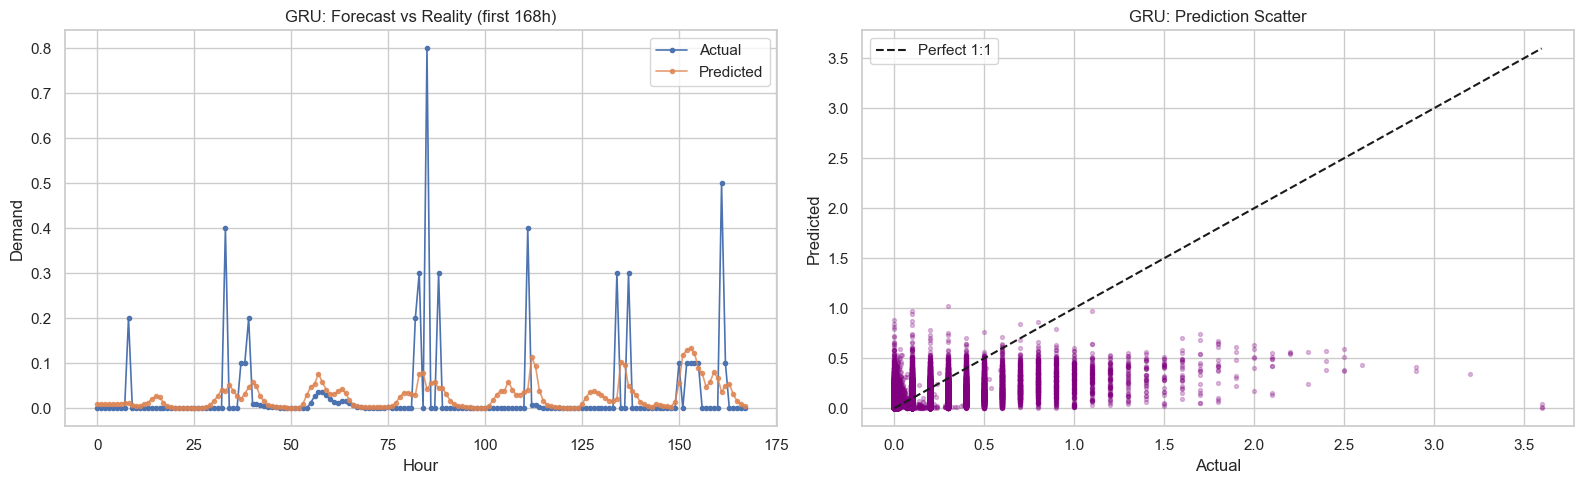

In [ ]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

mode = "latent" if config['training'].get('use_latent_demand', False) else "raw"
dl_train_path = f"DL_ready_train_{mode}.parquet"
dl_eval_path  = f"DL_ready_eval_{mode}.parquet"

if os.path.exists(dl_train_path) and os.path.exists(dl_eval_path):
    print(f"Loading DL-ready DataFrames from {dl_train_path} / {dl_eval_path}...")
    train_df = load_and_downcast(dl_train_path, sample_size=500000)
    val_df   = load_and_downcast(dl_eval_path,  sample_size=200000)
    target_col = 'true_demand'
    print(f"  Train: {len(train_df):,} | Val: {len(val_df):,} | Target: {target_col}")
else:
    print(f"No DL-ready parquet found. Falling back to raw data (no SAITS)...")
    train_df = load_and_downcast(config['data']['train_path'], sample_size=500000)
    train_df = add_days_since_last_sale(train_df)
    train_df = add_context_features(train_df)
    train_df['true_demand'] = train_df['units_ordered'].astype('float32')

    val_df = load_and_downcast(config['data']['eval_path'], sample_size=200000)
    val_df = add_days_since_last_sale(val_df)
    val_df = add_context_features(val_df)
    val_df['true_demand'] = val_df['units_ordered'].astype('float32')
    target_col = 'true_demand'

feature_cols = [c for c in config['data']['num_cols'] if c not in ('hour', 'day_of_week')]
feature_cols.append('days_since_last_sale')
group_cols   = ['store_id', 'product_id']

SEQ_LENGTH = 24

# ---------- LSTM ----------
lstm_model, val_loader, device = train_deep_learning(
    train_df, val_df, feature_cols, group_cols,
    target_col=target_col, model_type='lstm', epochs=20, hidden_size=128, seq_length=SEQ_LENGTH)
evaluate_pytorch_model(lstm_model, val_loader, device, model_name="LSTM")
del lstm_model; gc.collect(); torch.cuda.empty_cache()

# ---------- GRU  ----------
gru_model, val_loader, device = train_deep_learning(
    train_df, val_df, feature_cols, group_cols,
    target_col=target_col, model_type='gru', epochs=20, hidden_size=128, seq_length=SEQ_LENGTH)
evaluate_pytorch_model(gru_model, val_loader, device, model_name="GRU")
del gru_model; gc.collect(); torch.cuda.empty_cache()

## Chronos

In [19]:
def prepare_chronos_dataframe(df, use_imputed=True, agg_daily=False):
    """
    Formats the flat hourly DataFrame for Amazon Chronos.
    Requires 'id', 'timestamp', and 'target'.
    """
    print(" Formatting DataFrame for Chronos-2...")
    
    # 1. Create a clean DataFrame
    chronos_df = pd.DataFrame()
    
    # 2. Create unique Time Series ID (Store + Product)
    chronos_df['id'] = df['store_id'].astype(str) + "_" + df['product_id'].astype(str)
    
    # 3. Assign Timestamps
    chronos_df['timestamp'] = df['date']
    
    # 4. Assign the Target
    if use_imputed and 'true_demand' in df.columns:
        print("Using SAITS recovered 'true_demand' as target...")
        chronos_df['target'] = df['true_demand']
    else:
        print("Using raw 'units_ordered' as target...")
        chronos_df['target'] = df['units_ordered']
        
    # 5. Add Covariates (Chronos native ignores these, but good for GluonTS wrappers)
    covariates = ['discount', 'holiday', 'is_promotion']
    for cov in covariates:
        if cov in df.columns:
            chronos_df[cov] = df[cov]
            
    # 6. Handle Temporal Aggregation (Hourly vs Daily)
    if agg_daily:
        print("Aggregating hourly data into daily targets...")
        # Floor the timestamp to midnight
        chronos_df['timestamp'] = chronos_df['timestamp'].dt.floor('D')
        
        # Sum the sales, but take the max/first of the covariates
        agg_dict = {'target': 'sum'}
        for cov in covariates:
            if cov in chronos_df.columns:
                agg_dict[cov] = 'max' 
                
        chronos_df = chronos_df.groupby(['id', 'timestamp']).agg(agg_dict).reset_index()
    else:
        print("Maintaining hourly frequency...")
        
    # 7. Sort chronologically (CRITICAL for Deep Learning)
    chronos_df = chronos_df.sort_values(['id', 'timestamp']).reset_index(drop=True)
    
    print(f"Prepared Chronos DataFrame with {len(chronos_df)} rows")
    return chronos_df

In [22]:
def forecast_chronos2(chronos_df, future_df=None, prediction_length=168, batch_size=128):
    """
    Safely runs predict_df on massive datasets by slicing the Pandas DataFrame 
    into VRAM-safe chunks before hitting the model.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"\nLoading Chronos Model on {device}...")
    
    pipeline = Chronos2Pipeline.from_pretrained(
        "amazon/chronos-2",
        device_map=device,
        torch_dtype=torch.float32 
    )
    
    # 1. Grab all unique Time Series IDs
    unique_ids = chronos_df['id'].unique()
    print(f"Found {len(unique_ids):,} unique time series to forecast.")
    
    all_forecasts = []
    
    for i in tqdm(range(0, len(unique_ids), batch_size), desc="🧠 Forecasting Batches"):
        batch_ids = unique_ids[i : i + batch_size]
        batch_df = chronos_df[chronos_df['id'].isin(batch_ids)].copy()
        
        # Slice the covariates to match this specific batch of products
        if future_df is not None:
            batch_future_df = future_df[future_df['id'].isin(batch_ids)].copy()
        else:
            batch_future_df = None
            
        with torch.no_grad():
            batch_forecast = pipeline.predict_df(
                df=batch_df,
                future_df=batch_future_df,
                prediction_length=prediction_length,
                quantile_levels=[0.1, 0.5, 0.9],   
                id_column="id",                    
                timestamp_column="timestamp",      
                target="target"                   
            )
            
        all_forecasts.append(batch_forecast)
        
        del batch_df
        del batch_forecast
        if future_df is not None:
            del batch_future_df
            
        if torch.cuda.is_available():
            torch.cuda.empty_cache() 
        gc.collect()                 
        
    print("\nStitching chunked DataFrames together...")
    final_forecast_df = pd.concat(all_forecasts, ignore_index=True)
    
    # Enforce retail physics (no negative sales)
    for col in ['0.1', '0.5', '0.9']:
        final_forecast_df[col] = final_forecast_df[col].clip(lower=0).round(2)
    
    return final_forecast_df

In [23]:
def build_and_save_chronos_data(use_imputed=True, agg_daily=False):
    # 1. Point to the data generated by your Out-of-Core pipeline
    parquet_path = "DL_ready_train_latent.parquet"
    print(f"Loading raw data from: {parquet_path}")
    
    # 2. THE RAM SAVER: Only load exactly what prepare_chronos_dataframe asks for
    columns_to_load = ['store_id', 'product_id', 'date']
    
    # Add target column based on your preference
    if use_imputed:
        columns_to_load.append('true_demand')
    else:
        columns_to_load.append('units_ordered')
        
    # Check what covariates actually exist in the parquet file before loading
    import pyarrow.parquet as pq
    existing_cols = pq.ParquetFile(parquet_path).schema.names
    
    for cov in ['discount', 'holiday', 'is_promotion']:
        if cov in existing_cols:
            columns_to_load.append(cov)

    # 3. Load the perfectly trimmed DataFrame into RAM
    print(f"   -> Loading columns: {columns_to_load}")
    df_raw = pd.read_parquet(parquet_path, columns=columns_to_load)
    print(f"Successfully loaded {len(df_raw):,} rows.")
    
    # 4. Pass it to your existing preparation function
    chronos_df = prepare_chronos_dataframe(
        df=df_raw, 
        use_imputed=use_imputed, 
        agg_daily=agg_daily
    )
    
    # 5. Save the final lightweight Chronos file for your Ray Serve/Streamlit app
    output_name = "chronos_ready_train.parquet"
    chronos_df.to_parquet(output_name, index=False)
    print(f"Saved strictly formatted Chronos data to: {output_name}")
    
    return chronos_df

In [24]:
def build_future_df(train_df, eval_df, prediction_length=168):
    """
    Creates a mathematically perfect future dataframe with exactly 
    168 rows per ID, filling missing covariate gaps with 0, and 
    strictly enforcing data types.
    """   
    covariates = ['discount', 'holiday', 'is_promotion']
    
    # 1. Find the exact last timestamp for each ID
    last_dates = train_df.groupby('id')['timestamp'].max().reset_index()
    
    skeleton_rows = []
    
    # 2. Generate exactly 168 hours into the future
    for _, row in last_dates.iterrows():
        future_dates = pd.date_range(
            start=row['timestamp'] + pd.Timedelta(hours=1), 
            periods=prediction_length, 
            freq='h'
        )
        temp_df = pd.DataFrame({
            'id': row['id'],
            'timestamp': future_dates
        })
        skeleton_rows.append(temp_df)
        
    perfect_skeleton = pd.concat(skeleton_rows, ignore_index=True)
    
    # 3. Extract actual covariates
    actual_covariates = eval_df[['id', 'timestamp'] + covariates].copy()
    
    # 4. Merge onto the perfect grid
    perfect_future_df = pd.merge(
        perfect_skeleton, 
        actual_covariates, 
        on=['id', 'timestamp'], 
        how='left'
    )
    
    # 5. Fill missing hours with 0
    perfect_future_df[covariates] = perfect_future_df[covariates].fillna(0)
    for cov in covariates:
        perfect_future_df[cov] = perfect_future_df[cov].astype(train_df[cov].dtype)
        
    expected_rows = len(last_dates) * prediction_length
    print(f"Future DataFrame ready! Rows: {len(perfect_future_df):,} (Expected: {expected_rows:,})")
    
    return perfect_future_df

In [28]:
clean_chronos_df = build_and_save_chronos_data(use_imputed=True, agg_daily=False)
# Preview it to make sure it looks like a clean time series
print(clean_chronos_df.head())

Loading raw data from: DL_ready_train_latent.parquet
   -> Loading columns: ['store_id', 'product_id', 'date', 'true_demand', 'discount', 'holiday', 'is_promotion']
Successfully loaded 106,299,260 rows.
 Formatting DataFrame for Chronos-2...
Using SAITS recovered 'true_demand' as target...
Maintaining hourly frequency...
Prepared Chronos DataFrame with 106299260 rows
Saved strictly formatted Chronos data to: chronos_ready_train.parquet
      id           timestamp  target  discount  holiday  is_promotion
0  0_104 2024-03-28 00:00:00     0.0       1.0        0             0
1  0_104 2024-03-28 01:00:00     0.0       1.0        0             0
2  0_104 2024-03-28 02:00:00     0.0       1.0        0             0
3  0_104 2024-03-28 03:00:00     0.0       1.0        0             0
4  0_104 2024-03-28 04:00:00     0.0       1.0        0             0


In [ ]:
# 1. Define the cutoff point (Hide the last 168 hours / 1 week)
max_date = clean_chronos_df['timestamp'].max()
print(f"Max timestamp in data: {max_date}")
split_date = max_date - pd.Timedelta(hours=168)

# 2. Split into Train (Past) and Eval (Future Ground Truth)
train_chronos_df = clean_chronos_df[clean_chronos_df['timestamp'] <= split_date].copy()
eval_chronos_df = clean_chronos_df[clean_chronos_df['timestamp'] > split_date].copy()

print(f"Holding out {len(eval_chronos_df)} evaluation rows...")
print(f"Train set: {len(train_chronos_df)} rows | Eval set: {len(eval_chronos_df)} rows")
print(f"Train range: {train_chronos_df['timestamp'].min()} to {train_chronos_df['timestamp'].max()}")
print(f"Eval range: {eval_chronos_df['timestamp'].min()} to {eval_chronos_df['timestamp'].max()}")

num_weeks = clean_chronos_df['timestamp'].nunique() / (24 * 7)
num_weeks = int(num_weeks)
print(f"Total weeks of data: {num_weeks:.2f}")

covariates = ['id', 'timestamp', 'discount', 'holiday', 'is_promotion']
# 3. Generate Chronos predictions using ONLY the training data
future_df = build_future_df(
    train_df=train_chronos_df, 
    eval_df=eval_chronos_df, 
    prediction_length=168
)

chronos_backtest_predictions = forecast_chronos2(
    chronos_df=train_chronos_df,
    future_df=future_df,
    prediction_length=168,
)

# # 4. Evaluation
# # final_comparison_df = evaluate_chronos(
# #     actual_df=eval_chronos_df, 
# #     forecast_df=chronos_backtest_predictions
# # )


Max timestamp in data: 2024-06-25 23:00:00
Holding out 6699260 evaluation rows...
Train set: 99600000 rows | Eval set: 6699260 rows
Train range: 2024-03-28 00:00:00 to 2024-06-18 23:00:00
Eval range: 2024-06-19 00:00:00 to 2024-06-25 23:00:00
Total weeks of data: 12.00
🛠️ Building perfect 168-hour future skeleton...
✅ Future DataFrame ready! Rows: 8,400,000 (Expected: 8,400,000)


In [29]:
def evaluate_chronos(actual_df, forecast_df):
    """
    Merges Chronos predictions with actual holdout data, calculates WMAPE/RMSE,
    and generates the side-by-side visual dashboard.
    """
    print("Merging Chronos predictions with Ground Truth...")
    
    # Merge predictions with actuals based on ID and Exact Timestamp
    comparison_df = pd.merge(
        actual_df[['id', 'timestamp', 'target']], 
        forecast_df[['id', 'timestamp', 'chronos_prediction']],
        on=['id', 'timestamp'],
        how='inner'
    )
    
    if comparison_df.empty:
        raise ValueError("Error: The timestamps in your predictions do not overlap with your actual data! Make sure you did a proper train/test split.")
    print(comparison_df.sample(10))
    y_true = comparison_df['target']
    y_pred = comparison_df['chronos_prediction']
    
    # --- 1. Calculate Metrics ---
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    sum_actuals = y_true.sum() + 1e-9
    wmape = (np.abs(y_true - y_pred).sum() / sum_actuals) * 100
    bias = ((y_pred.sum() - y_true.sum()) / sum_actuals) * 100
    
    print("\n" + "="*40)
    print(" CHRONOS-T5 COMPREHENSIVE EVALUATION")
    print("="*40)
    print("Standard Metrics:")
    print(f"  • MAE:   {mae:.4f}")
    print(f"  • RMSE:  {rmse:.4f}\n")
    print("Retail Metrics:")
    print(f"  • WMAPE: {wmape:.2f}%")
    print(f"  • Bias:  {bias:+.2f}% (Overall volume diff)")
    print("="*40)
    
    # --- 2. Build the Dashboard ---
    # Find a high-volume product so the graph is interesting to look at
    top_items = comparison_df.groupby('id')['target'].sum().sort_values(ascending=False)
    plot_id = top_items.index[0]
    
    print(f"\nPlotting dashboard for Top Selling Item: {plot_id}")
    
    item_df = comparison_df[comparison_df['id'] == plot_id].sort_values('timestamp')
    
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))
    
    # Subplot 1: Time Series (Forecast vs Reality)
    axes[0].plot(range(len(item_df)), item_df['target'], marker='.', label='Actual Demand (SAITS)', color='#4C72B0')
    axes[0].plot(range(len(item_df)), item_df['chronos_prediction'], marker='.', label='Chronos Predicted', color='#DD8452')
    
    axes[0].set_title(f"Chronos T5: Forecast vs Reality (ID: {plot_id})")
    axes[0].set_xlabel("Hour Index")
    axes[0].set_ylabel("Demand Units")
    axes[0].legend()
    
    # Subplot 2: Prediction Scatter Plot (All Items)
    axes[1].scatter(comparison_df['target'], comparison_df['chronos_prediction'], 
                    alpha=0.4, color='#9b59b6', s=15)
    
    max_val = max(comparison_df['target'].max(), comparison_df['chronos_prediction'].max())
    if pd.isna(max_val) or max_val == 0: max_val = 1.0
        
    axes[1].plot([0, max_val], [0, max_val], 'k--', label="Perfect 1:1")
    axes[1].set_title("Chronos T5: Prediction Scatter (All Items)")
    axes[1].set_xlabel("Actual Demand")
    axes[1].set_ylabel("Predicted Demand")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    return comparison_df

In [30]:
def evaluate_multi_quantile(actual_df, forecast_df):
    """
    Evaluates Chronos 0.1, 0.5, and 0.9 quantiles simultaneously.
    """
    print("🔄 Merging Multi-Quantile predictions with Ground Truth...")
    
    comparison_df = pd.merge(
        actual_df[['id', 'timestamp', 'target']], 
        forecast_df[['id', 'timestamp', '0.1', '0.5', '0.9']],
        on=['id', 'timestamp'],
        how='inner'
    )
    
    y_true = comparison_df['target']
    sum_actuals = y_true.sum() + 1e-9
    
    print("\n" + "="*50)
    print(" CHRONOS-T5 MULTI-QUANTILE EVALUATION")
    print("="*50)
    
    # Calculate metrics for each quantile
    for q in ['0.1', '0.5', '0.9']:
        y_pred = comparison_df[q]
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        wmape = (np.abs(y_true - y_pred).sum() / sum_actuals) * 100
        bias = ((y_pred.sum() - y_true.sum()) / sum_actuals) * 100
        
        print(f"Quantile {q}:")
        print(f"  • WMAPE: {wmape:.2f}%  |  Bias: {bias:+.2f}%")
        print(f"  • MAE:   {mae:.4f}    |  RMSE: {rmse:.4f}\n")
    print("="*50)
    
    # --- Build the Multi-Quantile Dashboard ---
    top_items = comparison_df.groupby('id')['target'].sum().sort_values(ascending=False)
    plot_id = top_items.index[0]
    
    print(f"\nPlotting Confidence Dashboard for Item: {plot_id}")
    item_df = comparison_df[comparison_df['id'] == plot_id].sort_values('timestamp')
    
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(22, 6), gridspec_kw={'width_ratios': [2, 1]})
    
    # Subplot 1: Time Series with Confidence Band
    axes[0].plot(range(len(item_df)), item_df['target'], marker='.', label='Actual Demand', color='#4C72B0', linewidth=2)
    
    # Plot the Median (0.5)
    axes[0].plot(range(len(item_df)), item_df['0.5'], marker='', label='Median Forecast (0.5)', color='#DD8452', linewidth=2)
    
    # Fill the area between 0.1 and 0.9 to show confidence
    axes[0].fill_between(range(len(item_df)), item_df['0.1'], item_df['0.9'], color='#DD8452', alpha=0.2, label='0.1 - 0.9 Confidence Band')
    
    # Optional: Plot the 0.9 peak explicitly so you can see the highest guesses
    axes[0].plot(range(len(item_df)), item_df['0.9'], linestyle='--', color='#C44E52', alpha=0.6, label='Optimistic Peak (0.9)')

    axes[0].set_title(f"Forecast vs Reality with Confidence Intervals (ID: {plot_id})")
    axes[0].set_xlabel("Hour Index")
    axes[0].set_ylabel("Demand Units")
    axes[0].legend()
    
    # Subplot 2: Scatter Plot (Using Median 0.5)
    axes[1].scatter(comparison_df['target'], comparison_df['0.5'], alpha=0.4, color='#9b59b6', s=15, label='0.5 Quantile')
    axes[1].scatter(comparison_df['target'], comparison_df['0.9'], alpha=0.2, color='#C44E52', s=15, label='0.9 Quantile')
    
    max_val = max(comparison_df['target'].max(), comparison_df['0.9'].max())
    if pd.isna(max_val) or max_val == 0: max_val = 1.0
        
    axes[1].plot([0, max_val], [0, max_val], 'k--', label="Perfect 1:1")
    axes[1].set_title("Prediction Scatter (0.5 and 0.9 Quantiles)")
    axes[1].set_xlabel("Actual Demand")
    axes[1].set_ylabel("Predicted Demand")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    return comparison_df

🔄 Merging Multi-Quantile predictions with Ground Truth...

 🏆 CHRONOS-T5 MULTI-QUANTILE EVALUATION
Quantile 0.1:
  • WMAPE: 97.54%  |  Bias: -97.26%
  • MAE:   0.0607    |  RMSE: 0.1420

Quantile 0.5:
  • WMAPE: 83.46%  |  Bias: -67.43%
  • MAE:   0.0520    |  RMSE: 0.1145

Quantile 0.9:
  • WMAPE: 152.97%  |  Bias: +112.47%
  • MAE:   0.0952    |  RMSE: 0.1413


📊 Plotting Confidence Dashboard for Item: 18_300


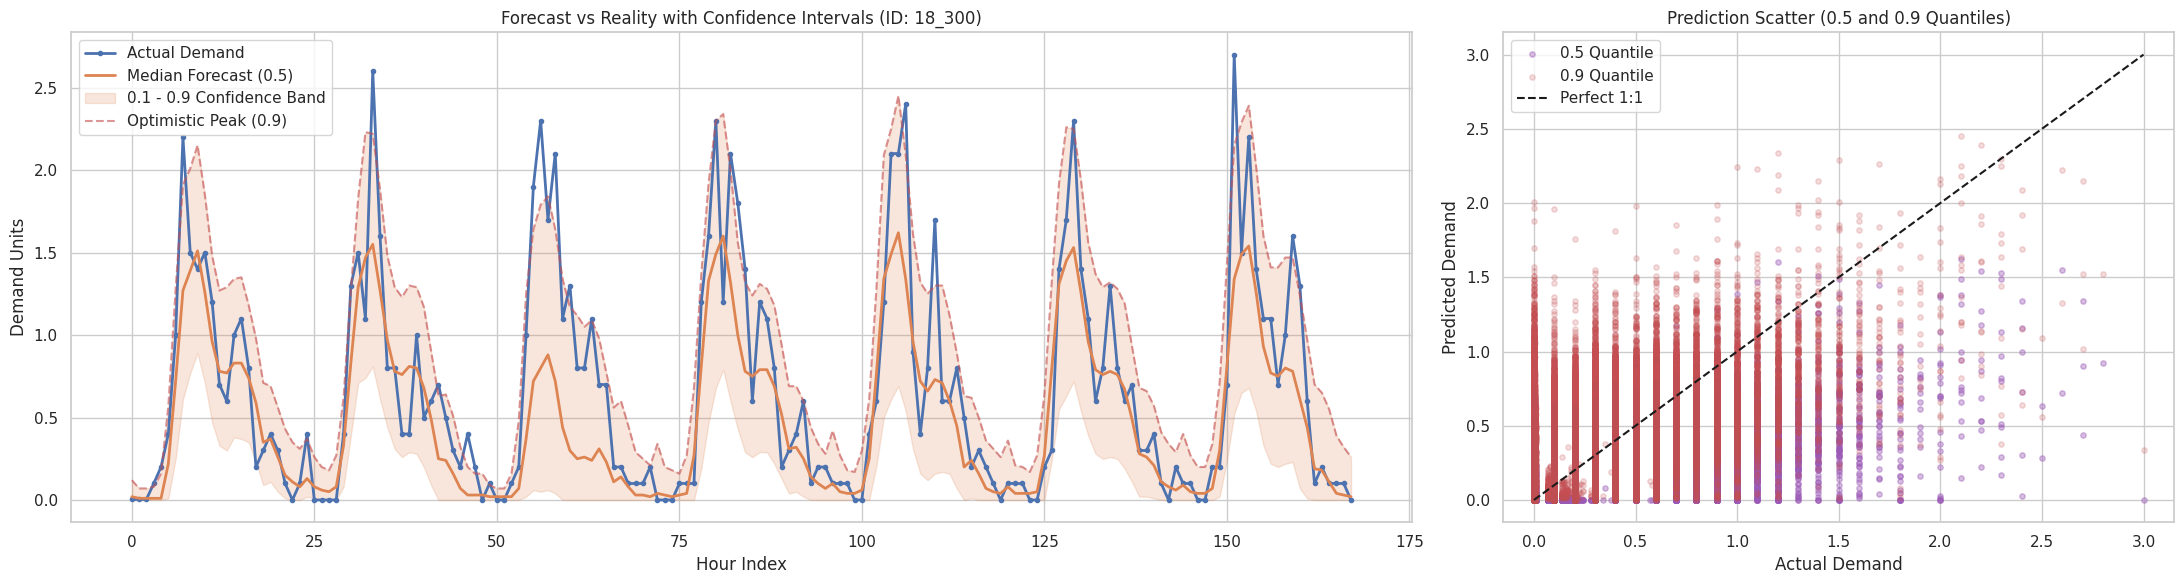

In [ ]:
multi_comparison_df = evaluate_multi_quantile(
    actual_df=eval_chronos_df, 
    forecast_df=chronos_backtest_predictions
)

In [ ]:
train_chronos_df.to_pickle("sample_chronos_hist.pkl")

future_df.to_pickle("sample_chronos_future.pkl")

print("Data successfully exported for the Streamlit UI!")

✅ Data successfully exported for the Streamlit UI!


In [ ]:
xgb_eval_df = pd.read_parquet("DL_ready_eval_latent.parquet")

xgb_eval_df['id'] = xgb_eval_df['store_id'].astype(str) + "_" + xgb_eval_df['product_id'].astype(str)

xgb_eval_df.to_pickle("sample_xgb.pkl")

print("'id' column successfully added and PKL updated!")

✅ 'id' column successfully added and PKL updated!


In [41]:
gc.collect()

7